In [1]:
import glob
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from itertools import product

from pathlib import Path
from MITRotor import IEA10MW

In [2]:
rotor = IEA10MW()

nElements = 26
nSections = 158

In [3]:
def extract_columns(file_list):
    data_dict = {}
    
    for file in file_list:
        with open(file, 'r') as f:
            lines = f.readlines()
            
            # Skip the header line and extract columns 1, 4, and 5
            data = np.loadtxt(lines[1:])[:, [0, 3, 4]]
            
            # Use the filename without the path and extension as the dictionary key
            key = Path(file).parent.name
            data_dict[key] = data
    
    return data_dict

In [4]:
file_list = glob.glob("/scratch/09909/smata/wrf_les_sweep/runs/10MW/gad_sweep/*/input_sounding")

data = extract_columns(file_list)

t = np.linspace(0,2*np.pi,nSections)
r = np.linspace(0,1,nElements)

R, T = np.meshgrid(r, t)

X = R * np.sin(T)
Y = (R * np.cos(T)) * rotor.R + 378

In [5]:
fontsize = 24
plt.rcParams['xtick.labelsize'] = 20 
plt.rcParams['ytick.labelsize'] = 20 

plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

In [6]:
casenames = [
r'sn030151_vn402010',
r'sn030151_vn201005',
r'sn030151_vn100503',
r'sn030151_vn050251',
r'sn030151_v000000',
r'sn030151_v050251',
r'sn030151_v100503',
r'sn030151_v201005',
r'sn030151_v402010',
r'sn020101_vn402010',
r'sn020101_vn201005',
r'sn020101_vn100503',
r'sn020101_vn050251',
r'sn020101_v000000',
r'sn020101_v050251',
r'sn020101_v100503',
r'sn020101_v201005',
r'sn020101_v402010',
r'sn010050_vn402010',
r'sn010050_vn201005',
r'sn010050_vn100503',
r'sn010050_vn050251',
r'sn010050_v000000',
r'sn010050_v050251',
r'sn010050_v100503',
r'sn010050_v201005',
r'sn010050_v402010',
r's000000_vn402010',
r's000000_vn201005',
r's000000_vn100503',
r's000000_vn050251',
r's000000_v000000',
r's000000_v050251',
r's000000_v100503',
r's000000_v201005',
r's000000_v402010',
r's010050_vn402010',
r's010050_vn201005',
r's010050_vn100503',
r's010050_vn050251',
r's010050_v000000',
r's010050_v050251',
r's010050_v100503',
r's010050_v201005',
r's010050_v402010',
r's020101_vn402010',
r's020101_vn201005',
r's020101_vn100503',
r's020101_vn050251',
r's020101_v000000',
r's020101_v050251',
r's020101_v100503',
r's020101_v201005',
r's020101_v402010',
r's030151_vn402010',
r's030151_vn201005',
r's030151_vn100503',
r's030151_vn050251',
r's030151_v000000',
r's030151_v050251',
r's030151_v100503',
r's030151_v201005',
r's030151_v402010'
]

wrfles_bem = []
for count, name in enumerate(casenames):
    wrfles_bem.append(dict(np.load('/scratch/09909/smata/wrf_les_sweep/runs/10MW/gad_sweep/'+casenames[count]+'_lite.npz')))

In [7]:
x_temp = [0,1,2,3,4,5,6]
y_temp = [8,7,6,5,4,3,2,1,0]
coords = [pair for pair in product(x_temp, y_temp)]

In [8]:
ind_rotor = np.zeros(len(coords), dtype=float)
ct_rotor  = np.zeros(len(coords), dtype=float)

ind_ann = np.zeros((nElements, len(coords)))
ct_ann  = np.zeros((nElements, len(coords)))

ind_loc = np.zeros((nElements, nSections, len(coords)))
ct_loc  = np.zeros((nElements, nSections, len(coords)))

for count,case in enumerate(casenames):
    u_func = interp1d(data[case][:,0], data[case][:,1], kind='linear')
    v_func = interp1d(data[case][:,0], data[case][:,2], kind='linear')

    u_inf = u_func(Y)
    v_inf = v_func(Y)

    # Compute induction
    r = wrfles_bem[count]['rOverR'] * rotor.R
    r_vec = wrfles_bem[count]['rOverR']

    # Compute induction
    ind = 1 - np.mean(wrfles_bem[count]['shapiroM'][0] * wrfles_bem[count]['u'],axis=0) / u_inf.T

    phi = np.deg2rad(np.mean(wrfles_bem[count]['phi'], axis=0))
    Cl = np.mean(wrfles_bem[count]['cl'], axis=0)
    Cd = np.mean(wrfles_bem[count]['cd'], axis=0)

    r =  (np.ones_like(Cd.T) * r).T

    chord = [4.649046,4.844576,5.216862,5.647547,5.931514,5.96353,5.812206,5.569981,5.273268,4.94348,4.598646,4.251929,3.911027,3.581805,3.269938,2.978544,2.70897,2.462014,2.237137,2.035348,1.855479,1.691271,1.526768,1.308778,0.7955106,0.5734]

    chord =  (np.ones_like(Cd.T) * chord).T

    sigma = (3 * chord) / (2 * np.pi * r)

    # Local Magnitude of U
    # W = np.mean(wrfles_bem[count]['vrel'], axis=0) / ((u_inf**2 + v_inf**2)**(1/2)).T

    # Rotor-average U
    U_azim = 1 / (2 * np.pi) * np.trapezoid(((u_inf**2 + v_inf**2)**(1/2)).T, np.linspace(0, 2*np.pi, nSections), axis=-1)
    U_bar = 2 * np.trapezoid(U_azim * r_vec, r_vec)
    W = np.mean(wrfles_bem[count]['vrel'], axis=0) / U_bar


    # Axial coefficient
    Cax = Cl * np.cos(phi) + Cd * np.sin(phi)

    # Local CT
    ct = sigma * W**2 * Cax

    ind_loc[:,:,count] = ind
    ct_loc[:,:,count]  = ct

    ct_annular  = 1/(2 * np.pi) * np.trapezoid(ct, np.linspace(0, 2*np.pi, nSections), axis=-1)
    ind_annular = 1/(2 * np.pi) * np.trapezoid(ind, np.linspace(0, 2*np.pi, nSections), axis=-1)

    ind_ann[:,count] = ind_annular
    ct_ann[:,count]  = ct_annular

    ct_rotor[count]  = 2 * np.trapezoid(ct_annular * wrfles_bem[count]['rOverR'], wrfles_bem[count]['rOverR'])
    ind_rotor[count] = 2 * np.trapezoid(ind_annular * wrfles_bem[count]['rOverR'], wrfles_bem[count]['rOverR'])

np.save("../rotor_coeffs/shapiro/10MW_rotor_averages_newCT.npy", [ind_rotor,ct_rotor])
np.save("../rotor_coeffs/shapiro/10MW_annular_averages_newCT.npy", [ind_ann,ct_ann])
np.save("../rotor_coeffs/shapiro/10MW_local_averages_newCT.npy", [ind_loc,ct_loc])

plt.show()

/tmp/ipykernel_174135/920910717.py:18: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  mesh = ax[coords[count][1],coords[count][0]].scatter(ind_loc[:,:,count], ct_loc[:,:,count], cmap='viridis', s=30, edgecolor='none',color='#176d2e',alpha=0.1)


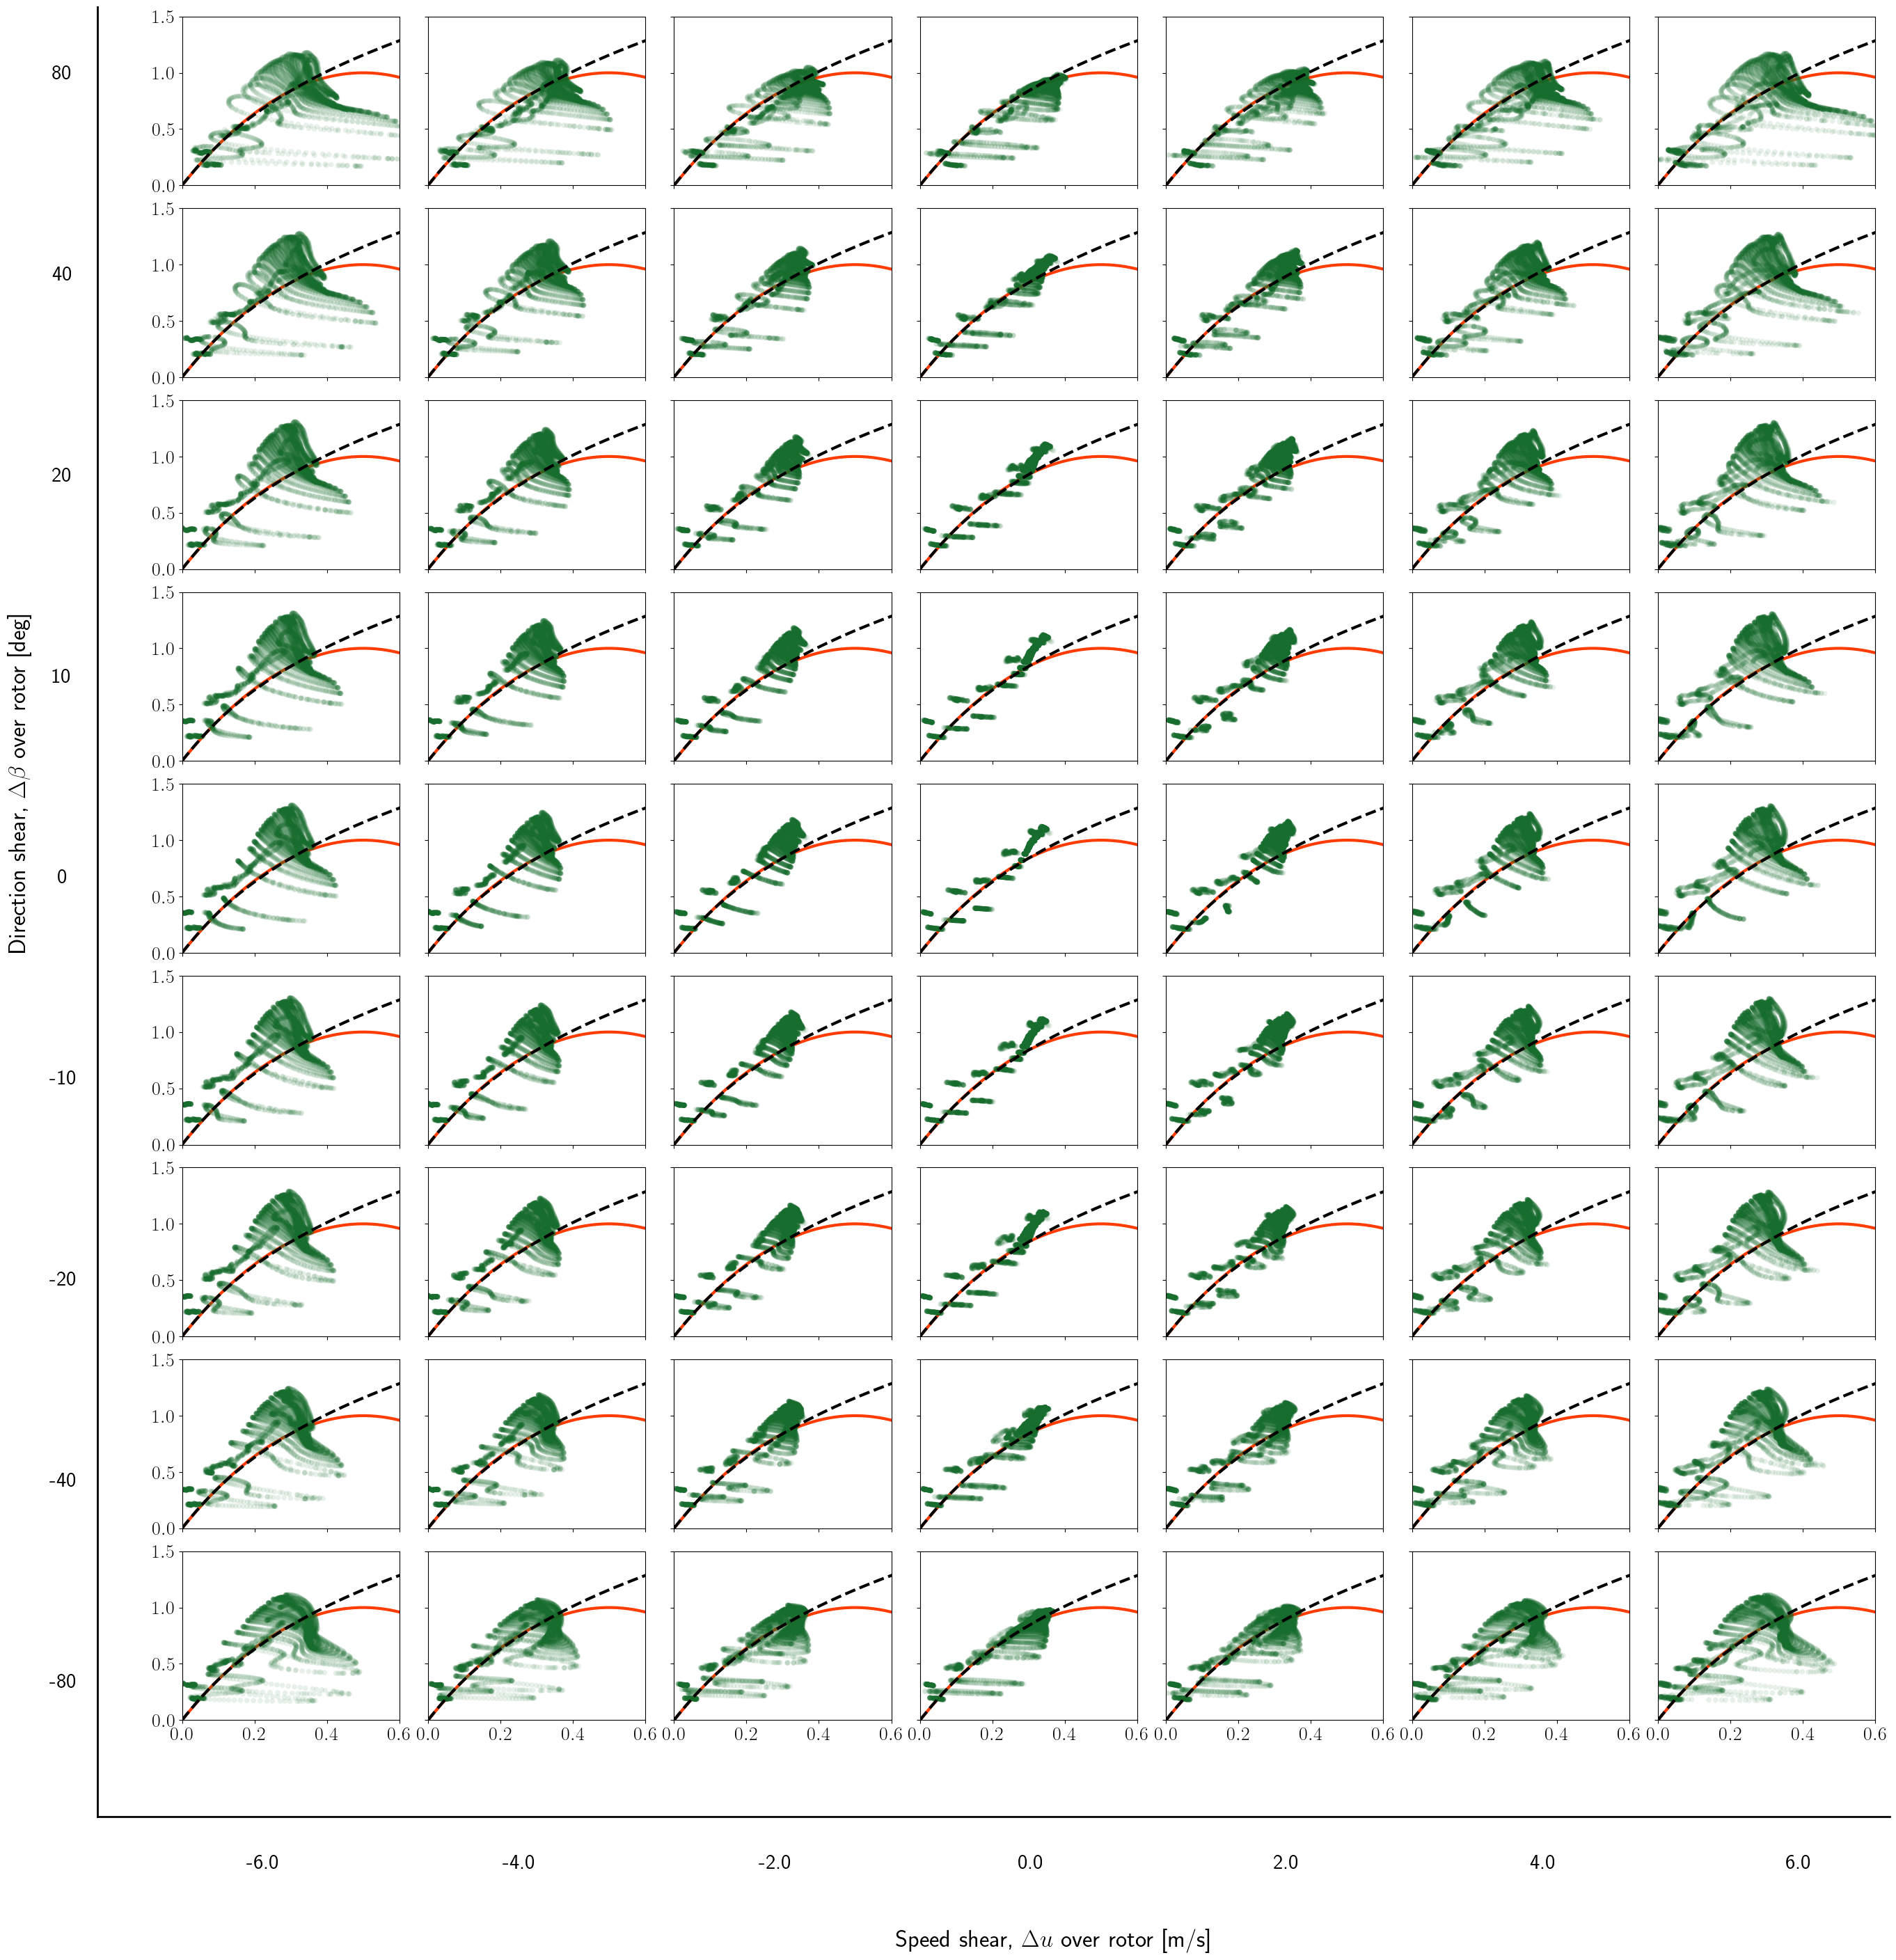

In [9]:
# Plot local

fig, ax = plt.subplots(nrows=9, ncols=7, figsize=(25, 25), constrained_layout=True,sharex=True, sharey=True)

for count,case in enumerate(casenames):

    a_mom = np.linspace(0,0.75,50)
    ct_mom = 4 * a_mom * (1 - a_mom)
    ax[coords[count][1],coords[count][0]].plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1)

    ct_mad = np.linspace(0,1.5,75)
    k1 = 0.2460
    k2 = 0.0586
    k3 = 0.0883
    a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
    ax[coords[count][1],coords[count][0]].plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2)

    mesh = ax[coords[count][1],coords[count][0]].scatter(ind_loc[:,:,count], ct_loc[:,:,count], cmap='viridis', s=30, edgecolor='none',color='#176d2e',alpha=0.1)

    ax[coords[count][1],coords[count][0]].set_xlim([0,0.6])
    ax[coords[count][1],coords[count][0]].set_ylim([0,1.5])


line_y = -0.04  # Y-position for the line (below the subplots)
line_x_start, line_x_end = -0.03, 1  # Start and end positions of the line (normalized coordinates)

# # Draw the line
fig.lines.extend([
    plt.Line2D([line_x_start, line_x_end], [line_y, line_y], color="black", transform=fig.transFigure, linewidth=2)
])

# # Add text to the number line
positions = np.linspace(line_x_start, line_x_end, 8)+0.095  # Adjust the number of points and spacing
labels = ['-6.0', '-4.0', '-2.0', '0.0', '2.0', '4.0', '6.0']  # Example labels

for pos, label in zip(positions, labels):
    fig.text(pos, line_y - 0.03, label, ha='center', fontsize=22)

# # Add a title for the number line
fig.text(0.52, line_y - 0.075, 'Speed shear, $\Delta u$ over rotor [m/s]', ha='center', fontsize=25)

line_x = -0.03  # Y-position for the line (below the subplots)
line_y_start, line_y_end = -0.04, 1  # Start and end positions of the line (normalized coordinates)

# # Draw the line
fig.lines.extend([
    plt.Line2D([line_x, line_x], [line_y_start, line_y_end], color="black", transform=fig.transFigure, linewidth=2)
])

# # Add text to the number line
positions = np.linspace(line_y_start, line_y_end, 10)+0.074  # Adjust the number of points and spacing
labels = ['-80', '-40', '-20', '-10', '0', '10', '20', '40', '80']  # Example labels

for pos, label in zip(positions, labels):
    fig.text(line_y - 0.01,pos, label, ha='center', fontsize=22)

# # Add a title for the number line
fig.text(-0.075,0.46, 'Direction shear, $\Delta \\beta$ over rotor [deg]', ha='center', fontsize=25,rotation=90)

plt.show()

/tmp/ipykernel_174135/3189520444.py:18: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  mesh = ax[coords[count][1],coords[count][0]].scatter(ind_ann[:,count], ct_ann[:,count], cmap='viridis', s=60, edgecolor='none',color='#176d2e',alpha=0.25)


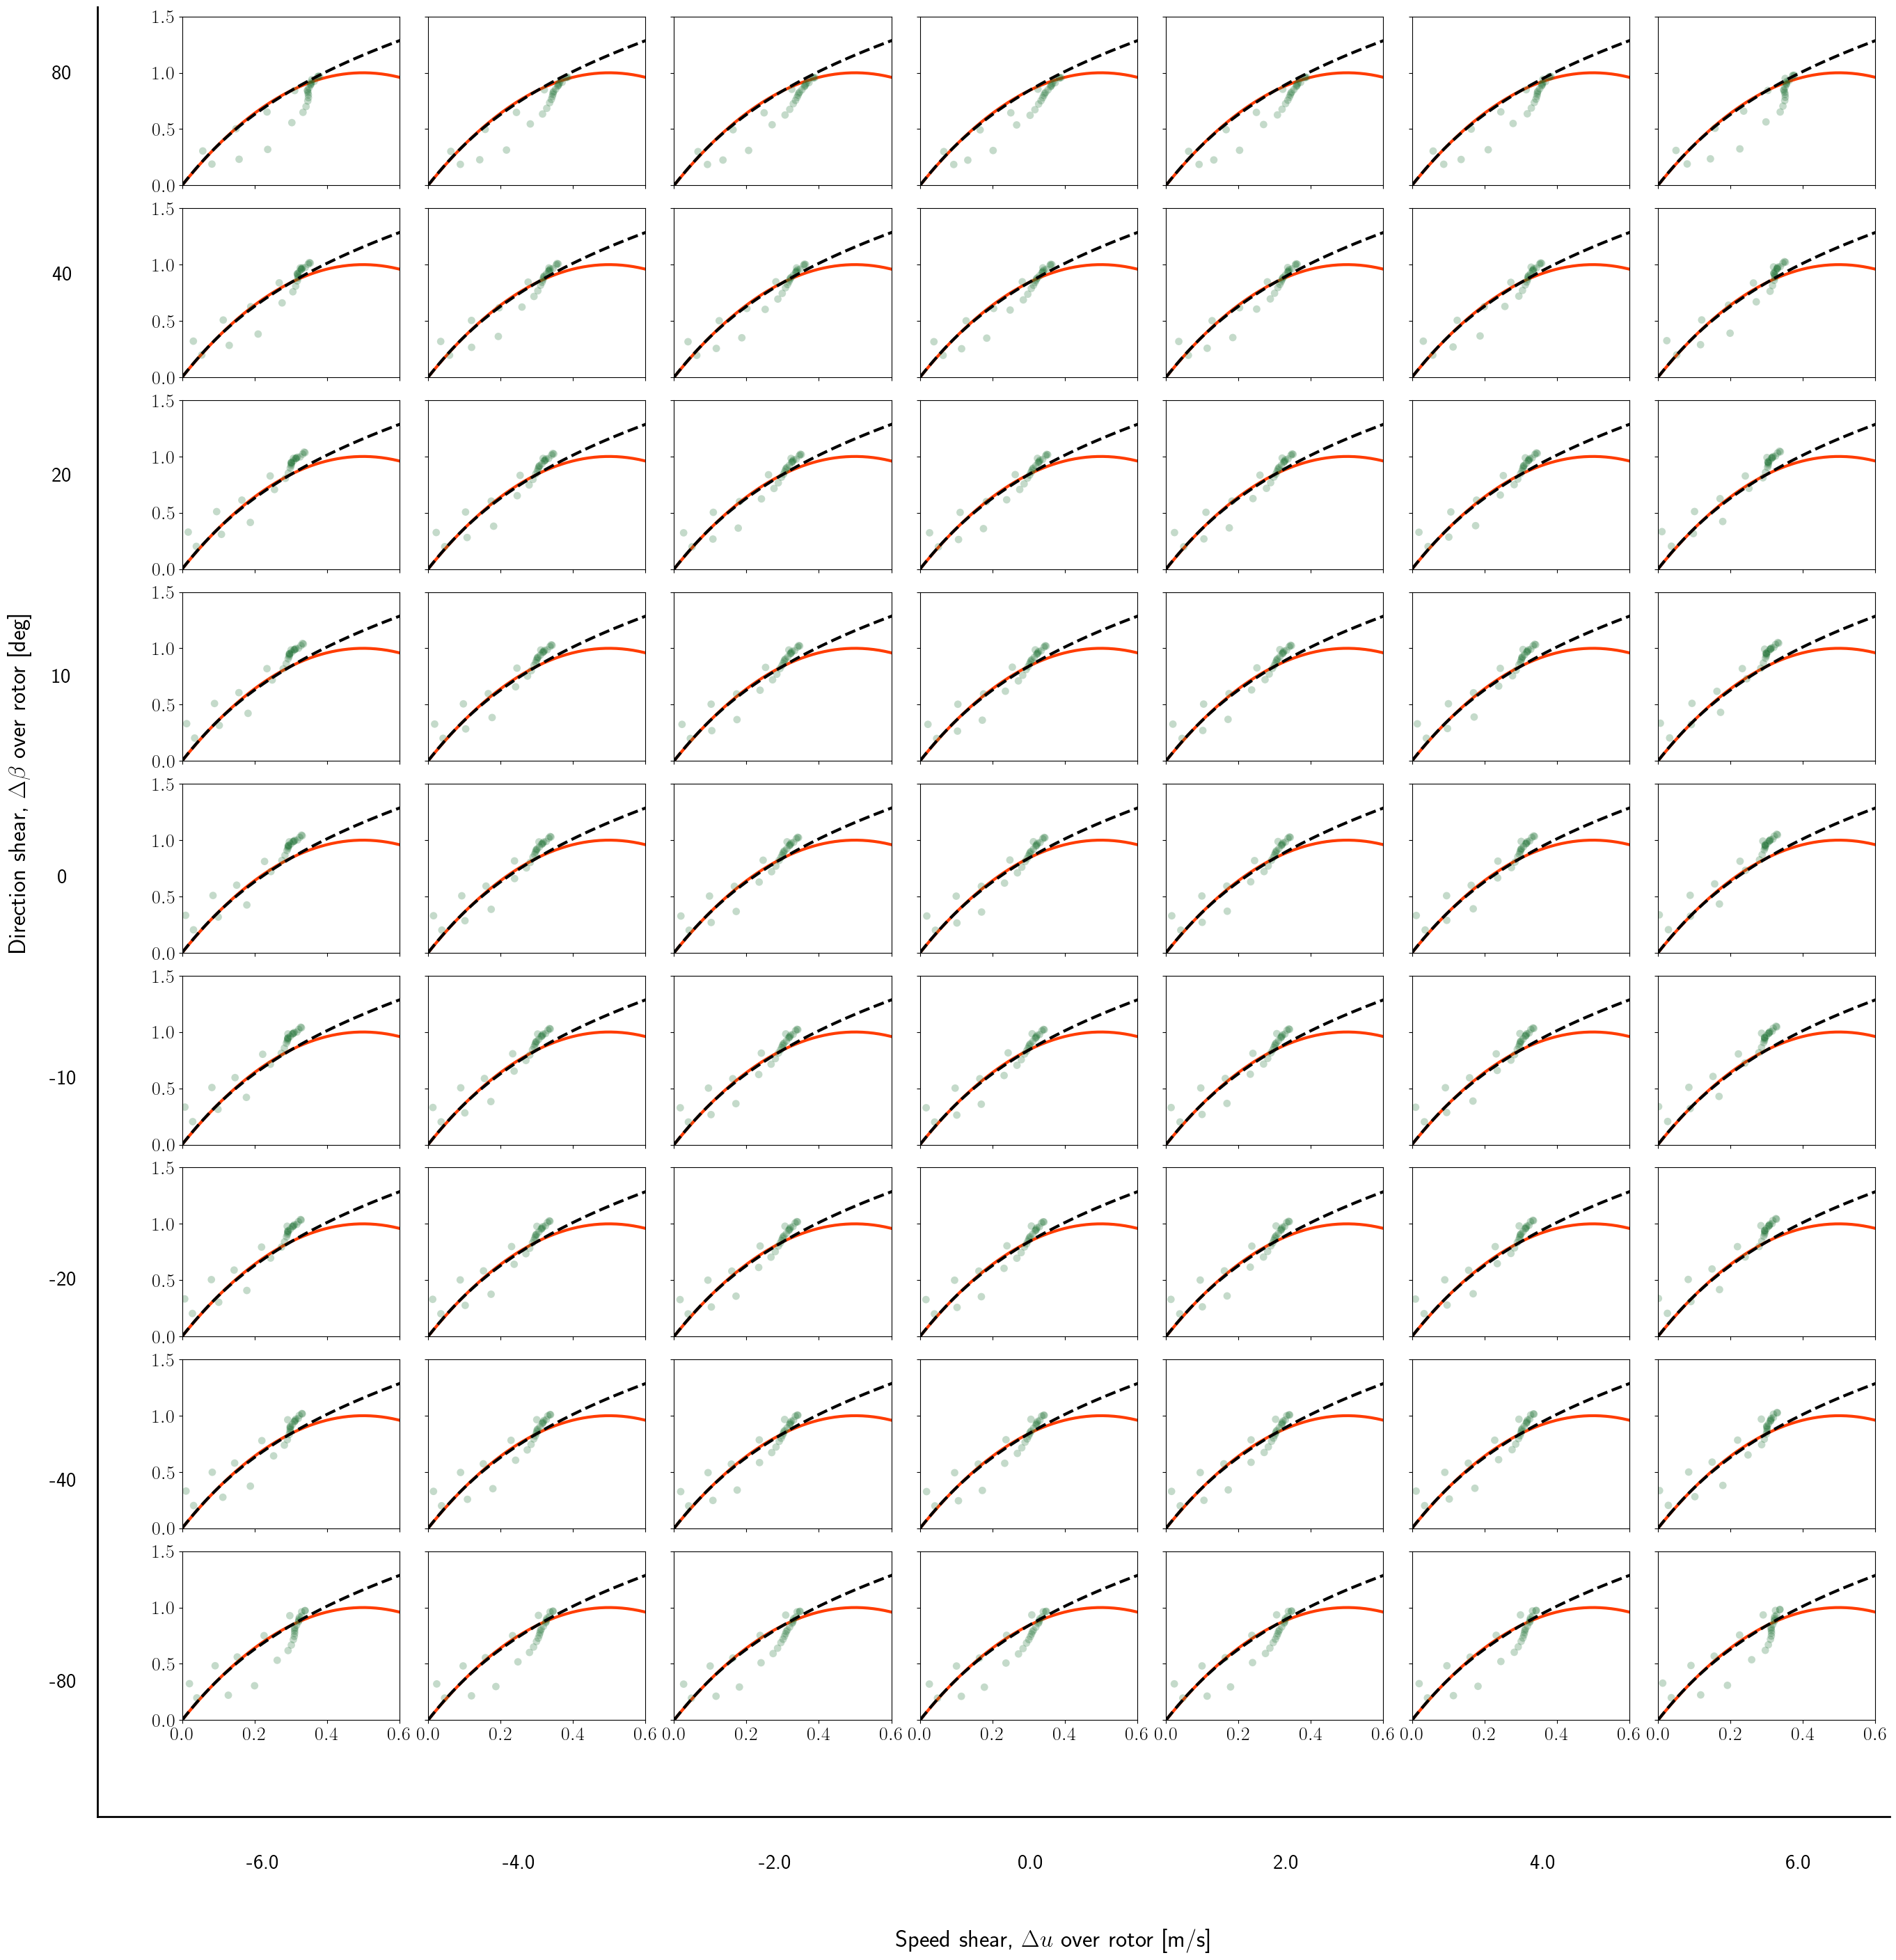

In [15]:
# Plot annular

fig, ax = plt.subplots(nrows=9, ncols=7, figsize=(25, 25), constrained_layout=True,sharex=True, sharey=True)

for count,case in enumerate(casenames):

    a_mom = np.linspace(0,0.75,50)
    ct_mom = 4 * a_mom * (1 - a_mom)
    ax[coords[count][1],coords[count][0]].plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1)

    ct_mad = np.linspace(0,1.5,75)
    k1 = 0.2460
    k2 = 0.0586
    k3 = 0.0883
    a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
    ax[coords[count][1],coords[count][0]].plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2)

    mesh = ax[coords[count][1],coords[count][0]].scatter(ind_ann[:,count], ct_ann[:,count], cmap='viridis', s=60, edgecolor='none',color='#176d2e',alpha=0.25)

    ax[coords[count][1],coords[count][0]].set_xlim([0,0.6])
    ax[coords[count][1],coords[count][0]].set_ylim([0,1.5])


line_y = -0.04  # Y-position for the line (below the subplots)
line_x_start, line_x_end = -0.03, 1  # Start and end positions of the line (normalized coordinates)

# # Draw the line
fig.lines.extend([
    plt.Line2D([line_x_start, line_x_end], [line_y, line_y], color="black", transform=fig.transFigure, linewidth=2)
])

# # Add text to the number line
positions = np.linspace(line_x_start, line_x_end, 8)+0.095  # Adjust the number of points and spacing
labels = ['-6.0', '-4.0', '-2.0', '0.0', '2.0', '4.0', '6.0']  # Example labels

for pos, label in zip(positions, labels):
    fig.text(pos, line_y - 0.03, label, ha='center', fontsize=22)

# # Add a title for the number line
fig.text(0.52, line_y - 0.075, 'Speed shear, $\Delta u$ over rotor [m/s]', ha='center', fontsize=25)

line_x = -0.03  # Y-position for the line (below the subplots)
line_y_start, line_y_end = -0.04, 1  # Start and end positions of the line (normalized coordinates)

# # Draw the line
fig.lines.extend([
    plt.Line2D([line_x, line_x], [line_y_start, line_y_end], color="black", transform=fig.transFigure, linewidth=2)
])

# # Add text to the number line
positions = np.linspace(line_y_start, line_y_end, 10)+0.074  # Adjust the number of points and spacing
labels = ['-80', '-40', '-20', '-10', '0', '10', '20', '40', '80']  # Example labels

for pos, label in zip(positions, labels):
    fig.text(line_y - 0.01,pos, label, ha='center', fontsize=22)

# # Add a title for the number line
fig.text(-0.075,0.46, 'Direction shear, $\Delta \\beta$ over rotor [deg]', ha='center', fontsize=25,rotation=90)

plt.show()

In [10]:
# Plot rotor

fig, ax = plt.subplots(nrows=9, ncols=7, figsize=(25, 25), constrained_layout=True,sharex=True, sharey=True)

for count,case in enumerate(casenames):

    a_mom = np.linspace(0,0.75,50)
    ct_mom = 4 * a_mom * (1 - a_mom)
    ax[coords[count][1],coords[count][0]].plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1)

    ct_mad = np.linspace(0,1.5,75)
    k1 = 0.2460
    k2 = 0.0586
    k3 = 0.0883
    a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
    ax[coords[count][1],coords[count][0]].plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2)

    mesh = ax[coords[count][1],coords[count][0]].scatter(ind_rotor[count], ct_rotor[count], cmap='viridis', s=60, edgecolor='none',color='#176d2e',alpha=1)

    ax[coords[count][1],coords[count][0]].set_xlim([0,0.6])
    ax[coords[count][1],coords[count][0]].set_ylim([0,1.5])


line_y = -0.04  # Y-position for the line (below the subplots)
line_x_start, line_x_end = -0.03, 1  # Start and end positions of the line (normalized coordinates)

# # Draw the line
fig.lines.extend([
    plt.Line2D([line_x_start, line_x_end], [line_y, line_y], color="black", transform=fig.transFigure, linewidth=2)
])

# # Add text to the number line
positions = np.linspace(line_x_start, line_x_end, 8)+0.095  # Adjust the number of points and spacing
labels = ['-6.0', '-4.0', '-2.0', '0.0', '2.0', '4.0', '6.0']  # Example labels

for pos, label in zip(positions, labels):
    fig.text(pos, line_y - 0.03, label, ha='center', fontsize=22)

# # Add a title for the number line
fig.text(0.52, line_y - 0.075, 'Speed shear, $\Delta u$ over rotor [m/s]', ha='center', fontsize=25)

line_x = -0.03  # Y-position for the line (below the subplots)
line_y_start, line_y_end = -0.04, 1  # Start and end positions of the line (normalized coordinates)

# # Draw the line
fig.lines.extend([
    plt.Line2D([line_x, line_x], [line_y_start, line_y_end], color="black", transform=fig.transFigure, linewidth=2)
])

# # Add text to the number line
positions = np.linspace(line_y_start, line_y_end, 10)+0.074  # Adjust the number of points and spacing
labels = ['-80', '-40', '-20', '-10', '0', '10', '20', '40', '80']  # Example labels

for pos, label in zip(positions, labels):
    fig.text(line_y - 0.01,pos, label, ha='center', fontsize=22)

# # Add a title for the number line
fig.text(-0.075,0.46, 'Direction shear, $\Delta \\beta$ over rotor [deg]', ha='center', fontsize=25,rotation=90)

plt.show()

/tmp/ipykernel_156556/987102720.py:18: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  mesh = ax[coords[count][1],coords[count][0]].scatter(ind_rotor[count], ct_rotor[count], cmap='viridis', s=60, edgecolor='none',color='#176d2e',alpha=1)


/tmp/ipykernel_2605291/792820596.py:22: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  mesh = ax[coords[count][1]].scatter(ind_rotor[count], ct_rotor[count], cmap='viridis', s=60, edgecolor='none',color='#176d2e',alpha=1)
/tmp/ipykernel_2605291/792820596.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[coords[count][1]].set_xticklabels(ax[coords[count][1]].get_xticklabels(), fontsize=10)
/tmp/ipykernel_2605291/792820596.py:28: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[coords[count][1]].set_yticklabels(ax[coords[count][1]].get_yticklabels(), fontsize=10)
/tmp/ipykernel_2605291/792820596.py:22: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  mesh = ax[coords[count][1]].scatter(ind_rotor[count], ct_rotor[count], cmap='viri

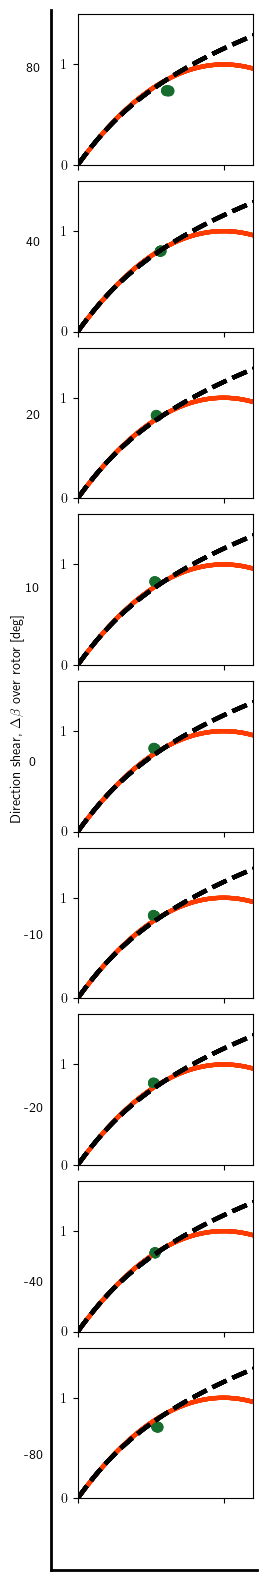

In [9]:
# Plot rotor

x_temp = [0,0,0,0,0,0,0]
y_temp = [8,7,6,5,4,3,2,1,0]
coords = [pair for pair in product(x_temp, y_temp)]

fig, ax = plt.subplots(nrows=9, ncols=1, figsize=(2, 15), constrained_layout=True,sharex=True, sharey=True)

for count,case in enumerate(casenames):

    a_mom = np.linspace(0,0.75,50)
    ct_mom = 4 * a_mom * (1 - a_mom)
    ax[coords[count][1]].plot(a_mom, ct_mom, '#ff3c00',linewidth=3,zorder=1)

    ct_mad = np.linspace(0,1.5,75)
    k1 = 0.2460
    k2 = 0.0586
    k3 = 0.0883
    a_mad = k3 * ct_mad**3 + k2 * ct_mad**2 + k1 * ct_mad
    ax[coords[count][1]].plot(a_mad, ct_mad, 'k--',linewidth=3,zorder=2)

    mesh = ax[coords[count][1]].scatter(ind_rotor[count], ct_rotor[count], cmap='viridis', s=60, edgecolor='none',color='#176d2e',alpha=1)

    ax[coords[count][1]].set_xlim([0,0.6])
    ax[coords[count][1]].set_ylim([0,1.5])

    ax[coords[count][1]].set_xticklabels(ax[coords[count][1]].get_xticklabels(), fontsize=10)
    ax[coords[count][1]].set_yticklabels(ax[coords[count][1]].get_yticklabels(), fontsize=10)


line_y = -0.04  # Y-position for the line (below the subplots)
line_x_start, line_x_end = -0.03, 1  # Start and end positions of the line (normalized coordinates)

# # Draw the line
fig.lines.extend([
    plt.Line2D([line_x_start, line_x_end], [line_y, line_y], color="black", transform=fig.transFigure, linewidth=2)
])

# # Add text to the number line
positions = np.linspace(line_x_start, line_x_end, 8)+0.095  # Adjust the number of points and spacing
labels = ['-6.0', '-4.0', '-2.0', '0.0', '2.0', '4.0', '6.0']  # Example labels

# for pos, label in zip(positions, labels):
#     fig.text(pos, line_y - 0.03, label, ha='center', fontsize=22)

# # Add a title for the number line
# fig.text(0.52, line_y - 0.075, 'Speed shear, $\Delta u$ over rotor [m/s]', ha='center', fontsize=25)

line_x = -0.03  # Y-position for the line (below the subplots)
line_y_start, line_y_end = -0.04, 1  # Start and end positions of the line (normalized coordinates)

# # Draw the line
fig.lines.extend([
    plt.Line2D([line_x, line_x], [line_y_start, line_y_end], color="black", transform=fig.transFigure, linewidth=2)
])

# # Add text to the number line
positions = np.linspace(line_y_start, line_y_end, 10)+0.074  # Adjust the number of points and spacing
labels = ['-80', '-40', '-20', '-10', '0', '10', '20', '40', '80']  # Example labels

for pos, label in zip(positions, labels):
    fig.text(line_y - 0.08,pos, label, ha='center', fontsize=10)

# # Add a title for the number line
fig.text(-0.2,0.46, 'Direction shear, $\Delta \\beta$ over rotor [deg]', ha='center', fontsize=10,rotation=90)

plt.show()